In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt


## Variables de prueba

Serie Original  SEV = S3-LCVER-CAZ

AB/2 de adquisicion = [2.0, 5.0, 10.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 92.0, 93.0, 95.0, 100.0] }

Rhoa adquiridos en campo = [1, 2.6, 13.6, 2.21, 2.26, 8.80, 7.46, 14.37, 36.49, 31.1, 4.67, 7.50, 13.87, 11.66, 46.65, 34.52, 45.64, 52.91, 8.90, 27.48, 22.23, 30.99, 40.04]

Primera evaluación se realiza un pronostico de los intervalos no muestreados de Rhoa y integrados en las aparturas ab2, correspondiente a los valores 876, 87, 88, 97 y 98, evaluando el pronostoco para estos intervalos

# Test 3

# LAMPAZO DEL NARANJO  S1-LN-EBSA

In [3]:
#LAMPAZO DEL NARANJO
# datos correspondientes a SEV en Lampazos del naranjo, sitio no integrado en el entrenamiento
ab2_values = [     2,      3,     5,     8,    10,    10,    12,    15,    25,    30,    45,    55,    65,    75,    85,    95,   110,   130,   140,    150,    170,    190,    210,    220,    240,    260,    280,    300,    310,      320]
rhoa_data =      [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.40, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, 0.0, 241.76, 0.0, 376.99, 122.61, 0.0, 0.0, 0.0, 17157.28]
rhoa_original =  [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.40, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, 116.13, 241.76, 402.26, 376.99, 122.61, 363.33, 147.65, 103.69, 17157.28]
ab2_data = ab2_values
n_points = 30

## RF

In [18]:
rf_multi = joblib.load("random_forest_multioutput_v2.joblib")#("rf_log_model.joblib") 
X_cols_original = joblib.load("random_forest_feature_columns_v2.joblib")  

Rhoa observados: [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.4, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, 0.0, 241.76, 0.0, 376.99, 122.61, 0.0, 0.0, 0.0, 17157.28]
Rhoa predichos (completos): [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.4, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, np.float64(200.50678422355762), 241.76, np.float64(207.9007045665147), 376.99, 122.61, np.float64(274.64087524606754), np.float64(294.912692129057), np.float64(309.78575072982164), 17157.28]


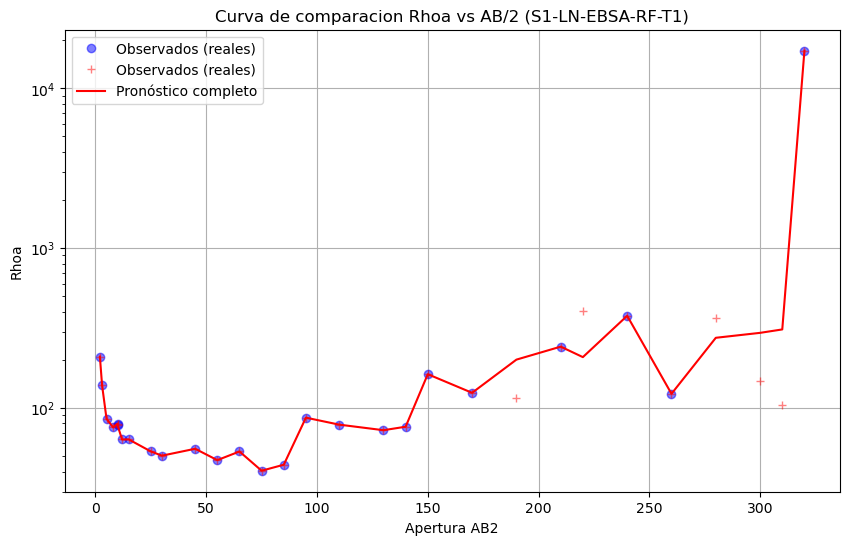

In [19]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols

df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]

for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]

y_pred = rf_multi.predict(df_new)[0] 

rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]

print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)

plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5)
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Rhoa')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-LN-EBSA-RF-T1)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-LN-EBSA-RF-T1.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

## GRB

In [20]:
gbr_multi = joblib.load("gbr_multioutput_v2.joblib")
X_cols_original = joblib.load("gbr_feature_columns_v2.joblib")

Rhoa observados: [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.4, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, 0.0, 241.76, 0.0, 376.99, 122.61, 0.0, 0.0, 0.0, 17157.28]
Rhoa predichos (completos): [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.4, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, np.float64(111.57640360728082), 241.76, np.float64(142.86972656389258), 376.99, 122.61, np.float64(209.89470898265597), np.float64(385.6557156650976), np.float64(198.88669511692433), 17157.28]


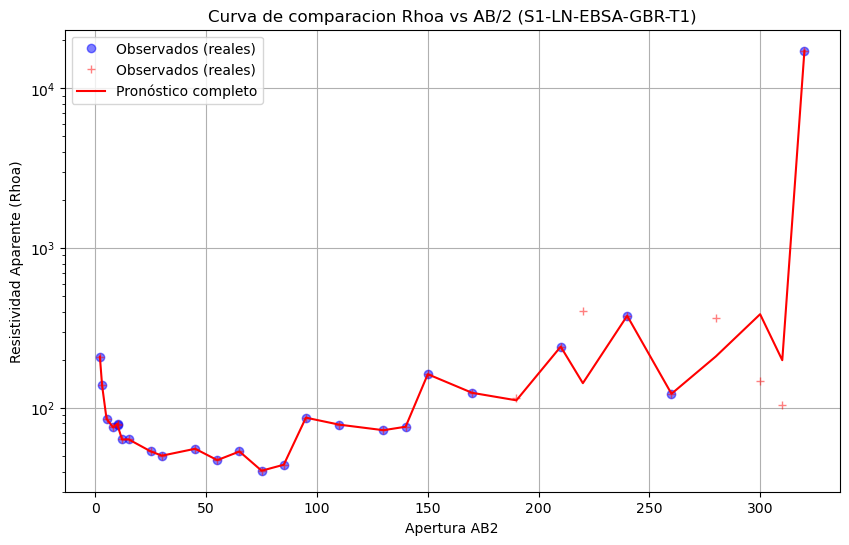

In [21]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]

for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]

y_pred = gbr_multi.predict(df_new)[0]

rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]

print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)

plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5)
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-LN-EBSA-GBR-T1)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-LN-EBSA-GBR-T1.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

Rhoa predichos (completos): [14.4, 81.15, 15.35, 26.64, 44.02, 75.55, 29.1, 27.57, 44.08, 8.05, 19.31, 26.602318090798132, 17.860309917803328, 15.16833675091321, 11.84677565732481, 9.175542713638869, 6.261417495089926, 7.389681687618631, 5.254099184152225, 7.435249815603227, 7.205924187380515]

Rhoa predichos (completos): [14.4, 81.15, 15.35, 26.64, 44.02, 75.55, 29.1, 27.57, 44.08, 8.05, 19.31, 26.602318090798132, 17.860309917803328, 15.16833675091321, 11.846775657324809, 9.175542713638869, 6.261417495089926, 7.389681687618631, 5.254099184152225, 7.4352498156032265, 7.205924187380515]

## VSM

In [ ]:
svm_multi = joblib.load("svm_multioutput_v2.joblib")
X_cols_original = joblib.load("svm_feature_columns_v2.joblib")

Rhoa observados: [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.4, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, 0.0, 241.76, 0.0, 376.99, 122.61, 0.0, 0.0, 0.0, 17157.28]
Rhoa predichos (completos): [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.4, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, np.float64(1546.8077638875093), 241.76, np.float64(1594.1693385837534), 376.99, 122.61, np.float64(1676.4268586817445), np.float64(1715.2590286085856), np.float64(1754.3257266893959), 17157.28]


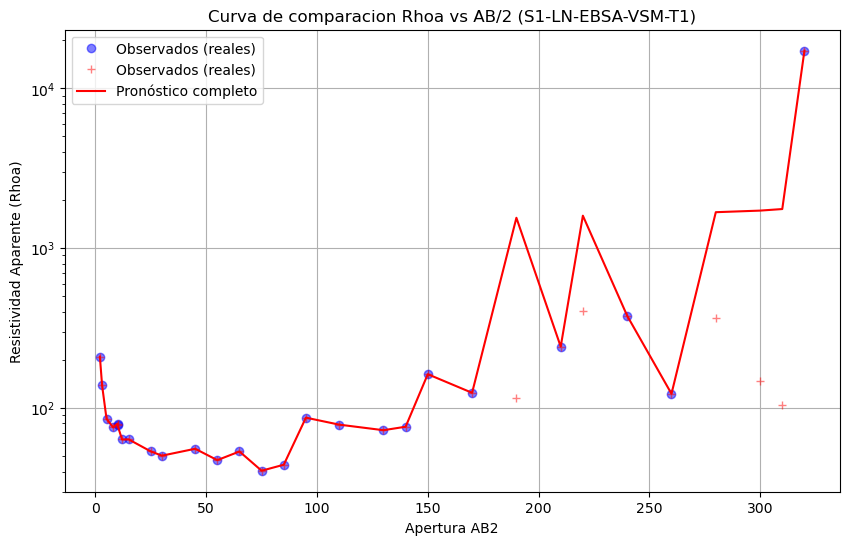

In [23]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols

df_new = pd.DataFrame(columns=X_cols_original) 
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]

for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]

y_pred = svm_multi.predict(df_new)[0] 

rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]

print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)

plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo') 
plt.yscale('log') 
plt.xscale('linear') 
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-LN-EBSA-VSM-T1)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-LN-EBSA-VSM-T1.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

## VSM - 2

In [4]:
svm_multi = joblib.load("svm_multioutput_v3.joblib")
X_cols_original = joblib.load("svm_feature_columns_v3.joblib")

Rhoa observados: [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.4, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, 0.0, 241.76, 0.0, 376.99, 122.61, 0.0, 0.0, 0.0, 17157.28]
Rhoa predichos (completos): [209.44, 138.23, 85.57, 75.48, 79.79, 77.79, 63.47, 63.56, 53.44, 50.28, 55.54, 47.15, 53.4, 40.48, 44.13, 86.93, 78.62, 72.56, 76.29, 162.54, 124.33, 1696.7466380565693, 241.76, 1746.9080505799475, 376.99, 122.61, 1836.392571638799, 1859.9972023061764, 1880.5609356018304, 17157.28]


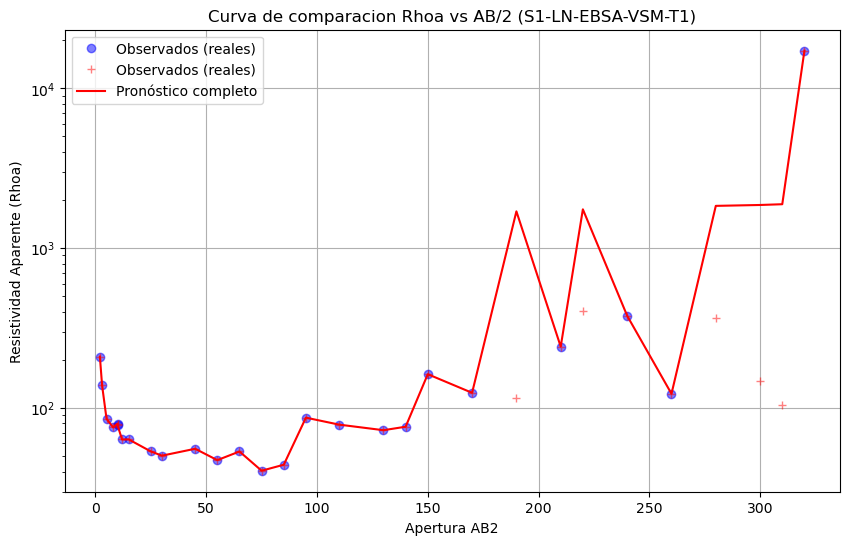

In [5]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols

df_new = pd.DataFrame(columns=X_cols_original) 
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]

for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]

y_pred = svm_multi.predict(df_new)[0] 

rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]

print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)

plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo') 
plt.yscale('log') 
plt.xscale('linear') 
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-LN-EBSA-VSM-T1)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-LN-EBSA-VSM-T1.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# LOS OLIVOS II S1-EGH-OLIVOS

In [8]:
# LOS OLIVOS II  sev 1
ab2_values = [2, 5, 10, 10, 20, 30, 40, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 150, 160, 170, 180, 190, 210, 230, 250]
rhoa_data =  [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, 0, 0, 90.45, 95.91, 103.92, 0, 109.11, 110.01, 112.33, 115.67, 117.57, 0, 114.43, 114.15, 116.06, 107.76, 0, 0, 0]
rhoa_original =  [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, 107.91, 86.83, 90.45, 95.91, 103.92, 109.63, 109.11, 110.01, 112.33, 115.67, 117.57, 37.79, 114.43, 114.15, 116.06, 107.76, 112.15, 119.37, 114.78]
n_points = 25

# RF

In [25]:

rf_multi = joblib.load("random_forest_multioutput_v2.joblib")  
X_cols_original = joblib.load("random_forest_feature_columns_v2.joblib")  

Rhoa observados: [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, 0, 0, 90.45, 95.91, 103.92, 0, 109.11, 110.01, 112.33, 115.67, 117.57, 0, 114.43, 114.15, 116.06, 107.76, 0, 0, 0]
Rhoa predichos (completos): [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, np.float64(283.629287143179), np.float64(175.94324655176774), 90.45, 95.91, 103.92, np.float64(92.03873456694365), 109.11, 110.01, 112.33, 115.67, 117.57, np.float64(108.1945617644396), 114.43, 114.15, 116.06, 107.76, np.float64(86.94217591554467), np.float64(81.23232715705471), np.float64(70.46503499436564)]


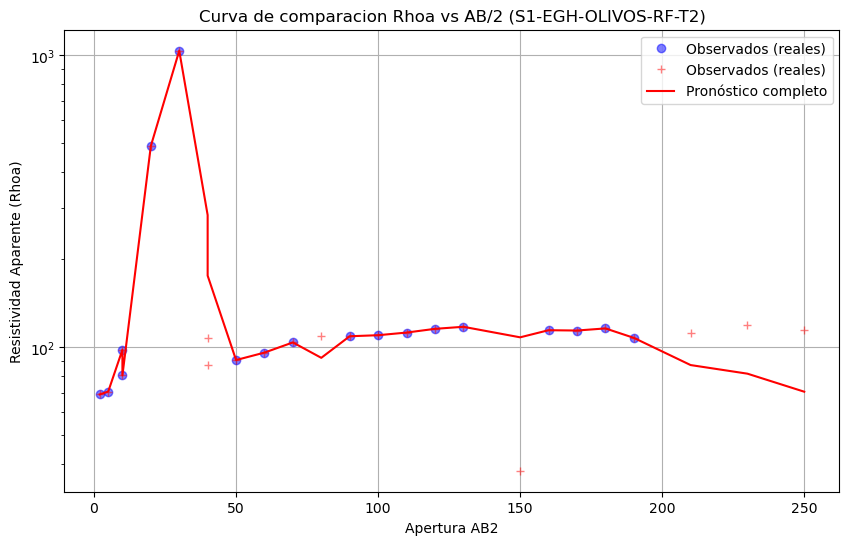

In [26]:

ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original) 
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = rf_multi.predict(df_new)[0]  


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo') 
plt.yscale('log')  
plt.xscale('linear')  
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-EGH-OLIVOS-RF-T2)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-EGH-OLIVOS-RF-T2.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# GBR

In [27]:
gbr_multi = joblib.load("gbr_multioutput_v2.joblib")
X_cols_original = joblib.load("gbr_feature_columns_v2.joblib")

Rhoa observados: [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, 0, 0, 90.45, 95.91, 103.92, 0, 109.11, 110.01, 112.33, 115.67, 117.57, 0, 114.43, 114.15, 116.06, 107.76, 0, 0, 0]
Rhoa predichos (completos): [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, np.float64(367.5370421233339), np.float64(242.34117955622796), 90.45, 95.91, 103.92, np.float64(96.73712294517765), 109.11, 110.01, 112.33, 115.67, 117.57, np.float64(83.62009722565995), 114.43, 114.15, 116.06, 107.76, np.float64(87.51527271589887), np.float64(98.69759647549618), np.float64(87.65951310312896)]


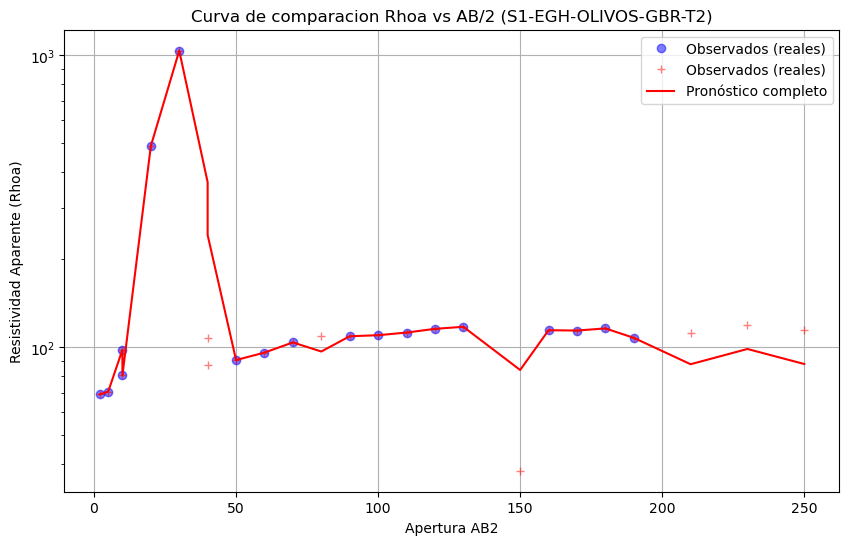

In [28]:

ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)  
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = gbr_multi.predict(df_new)[0]  


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')  
plt.yscale('log')  
plt.xscale('linear') 
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-EGH-OLIVOS-GBR-T2)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-EGH-OLIVOS-GBR-T2.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# SVM

In [29]:
svm_multi = joblib.load("svm_multioutput_v2.joblib")
X_cols_original = joblib.load("svm_feature_columns_v2.joblib") 

Rhoa observados: [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, 0, 0, 90.45, 95.91, 103.92, 0, 109.11, 110.01, 112.33, 115.67, 117.57, 0, 114.43, 114.15, 116.06, 107.76, 0, 0, 0]
Rhoa predichos (completos): [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, np.float64(255.45950053956574), np.float64(241.99794938454693), 90.45, 95.91, 103.92, np.float64(56.152828245557004), 109.11, 110.01, 112.33, 115.67, 117.57, np.float64(266.43439027406225), 114.43, 114.15, 116.06, 107.76, np.float64(270.17413006062634), np.float64(264.3961124650302), np.float64(264.35858761881696)]


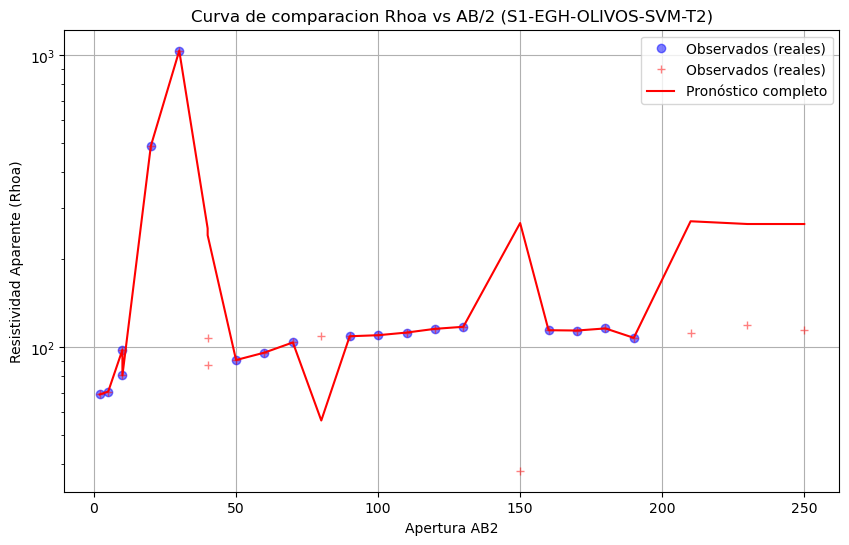

In [30]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = svm_multi.predict(df_new)[0]


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-EGH-OLIVOS-SVM-T2)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-EGH-OLIVOS-SVM-T2.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

## VSM - 2

In [9]:
svm_multi = joblib.load("svm_multioutput_v3.joblib")
X_cols_original = joblib.load("svm_feature_columns_v3.joblib") 

Rhoa observados: [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, 0, 0, 90.45, 95.91, 103.92, 0, 109.11, 110.01, 112.33, 115.67, 117.57, 0, 114.43, 114.15, 116.06, 107.76, 0, 0, 0]
Rhoa predichos (completos): [68.97, 70.54, 98.06, 80.12, 488.98, 1036.73, 299.4075030899035, 285.25167454356307, 90.45, 95.91, 103.92, 256.64922412031274, 109.11, 110.01, 112.33, 115.67, 117.57, 247.57830344263053, 114.43, 114.15, 116.06, 107.76, 252.97158057732233, 254.08953616969734, 256.12377206990817]


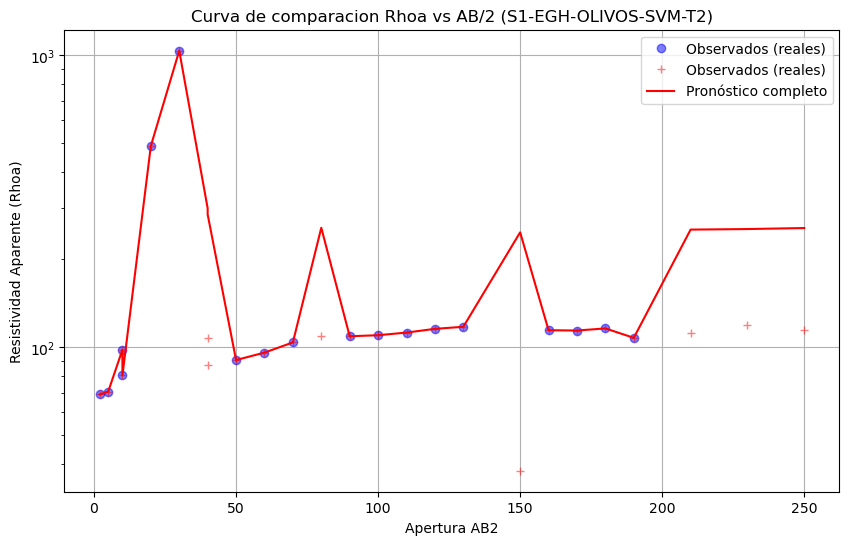

In [10]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = svm_multi.predict(df_new)[0]


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-EGH-OLIVOS-SVM-T2)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-EGH-OLIVOS-SVM-T2.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

## LAMPAZO DEL NARANJO  S2-LN-EBSA

In [11]:
ab2_values =     [    3,      4,     5,      8,     10,     15,    25,   30,   40,    50,    70,    80,    100,    120,   130,   140,    150,    170,    180,    190,    210,    230,    250,    260,    280,    290]
rhoa_data =      [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56,     0,      0,      0,      0,      0,      0,      0,      0, 153.89, 313.65, 592.77]
rhoa_original =  [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, 76.29, 159.71, 108.10, 121.31, 130.22, 177.49, 183.46, 194.49, 153.89, 313.65, 592.77]
n_points = 26

# RF

In [32]:
rf_multi = joblib.load("random_forest_multioutput_v2.joblib")  
X_cols_original = joblib.load("random_forest_feature_columns_v2.joblib")  

Rhoa observados: [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, 0, 0, 0, 0, 0, 0, 0, 0, 153.89, 313.65, 592.77]
Rhoa predichos (completos): [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, np.float64(213.7826267171374), np.float64(218.55330342345596), np.float64(197.95645506349592), np.float64(165.3852117922471), np.float64(143.59346255668072), np.float64(207.38165286689656), np.float64(207.36318104574949), np.float64(214.31215003202303), 153.89, 313.65, 592.77]


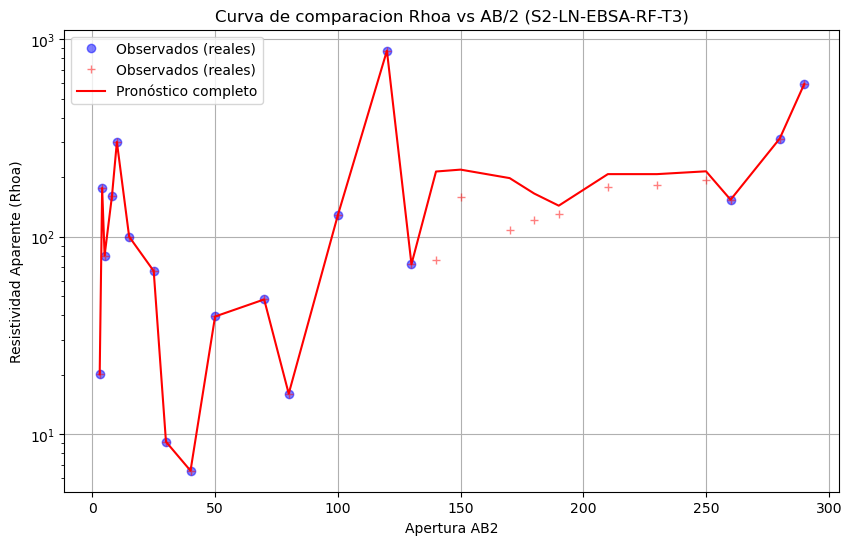

In [33]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original) 
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = rf_multi.predict(df_new)[0]  


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo') 
plt.yscale('log')  
plt.xscale('linear')  
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S2-LN-EBSA-RF-T3)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S2-LN-EBSA-RF-T3.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# GBR

In [34]:
gbr_multi = joblib.load("gbr_multioutput_v2.joblib")
X_cols_original = joblib.load("gbr_feature_columns_v2.joblib")

Rhoa observados: [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, 0, 0, 0, 0, 0, 0, 0, 0, 153.89, 313.65, 592.77]
Rhoa predichos (completos): [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, np.float64(318.58678471257457), np.float64(307.10041430860366), np.float64(246.15561331692896), np.float64(52.45350894747971), np.float64(50.27638839164357), np.float64(132.53785837570132), np.float64(134.06358881974504), np.float64(169.3245575638842), 153.89, 313.65, 592.77]


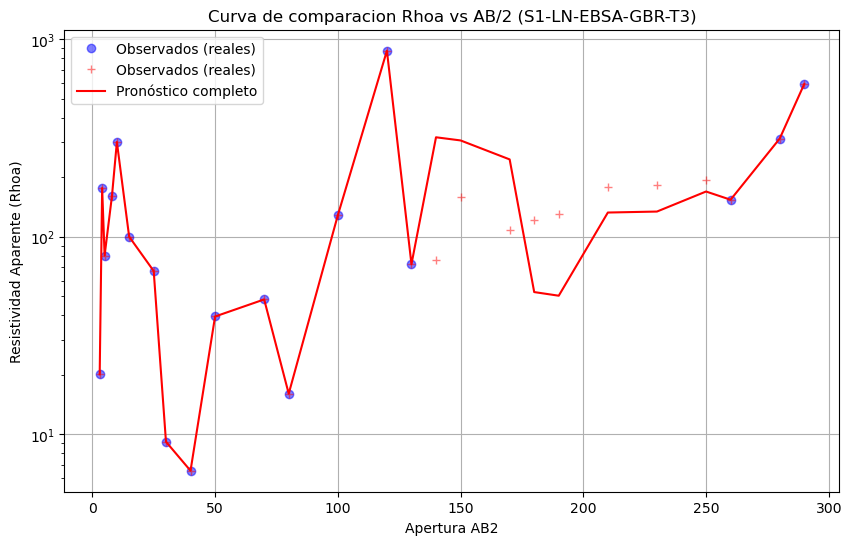

In [35]:

ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)  
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = gbr_multi.predict(df_new)[0]  


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')  
plt.yscale('log')  
plt.xscale('linear') 
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-LN-EBSA-GBR-T3)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-LN-EBSA-GBR-T3.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')


plt.show()

# SVM

In [36]:
svm_multi = joblib.load("svm_multioutput_v2.joblib")
X_cols_original = joblib.load("svm_feature_columns_v2.joblib") 

Rhoa observados: [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, 0, 0, 0, 0, 0, 0, 0, 0, 153.89, 313.65, 592.77]
Rhoa predichos (completos): [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, np.float64(326.0918050657997), np.float64(329.8867138979547), np.float64(342.43924702934805), np.float64(341.25476854587737), np.float64(345.35113639381416), np.float64(347.0889459346754), np.float64(345.9452226161113), np.float64(340.65953577248547), 153.89, 313.65, 592.77]


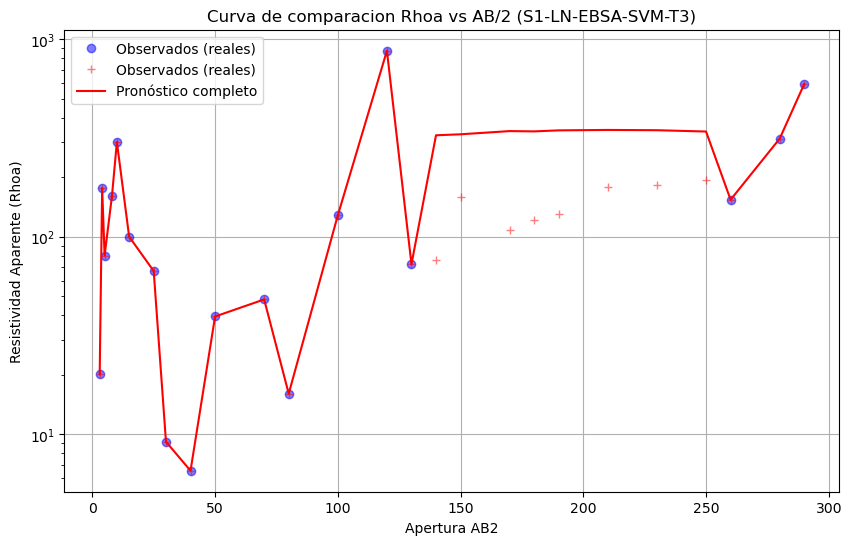

In [37]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = svm_multi.predict(df_new)[0]


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-LN-EBSA-SVM-T3)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-LN-EBSA-SVM-T3.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

## VSM - 2

In [12]:
svm_multi = joblib.load("svm_multioutput_v3.joblib")
X_cols_original = joblib.load("svm_feature_columns_v3.joblib") 

Rhoa observados: [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, 0, 0, 0, 0, 0, 0, 0, 0, 153.89, 313.65, 592.77]
Rhoa predichos (completos): [20.11, 176.45, 80.28, 160.85, 301.59, 100.04, 67.04, 9.17, 6.54, 39.46, 48.14, 16.05, 128.33, 873.66, 72.56, 315.4510353515451, 319.2591030906469, 317.51252447922536, 325.7740637902465, 342.7140001197524, 350.2749410684582, 354.35037431580685, 354.64565891353436, 153.89, 313.65, 592.77]


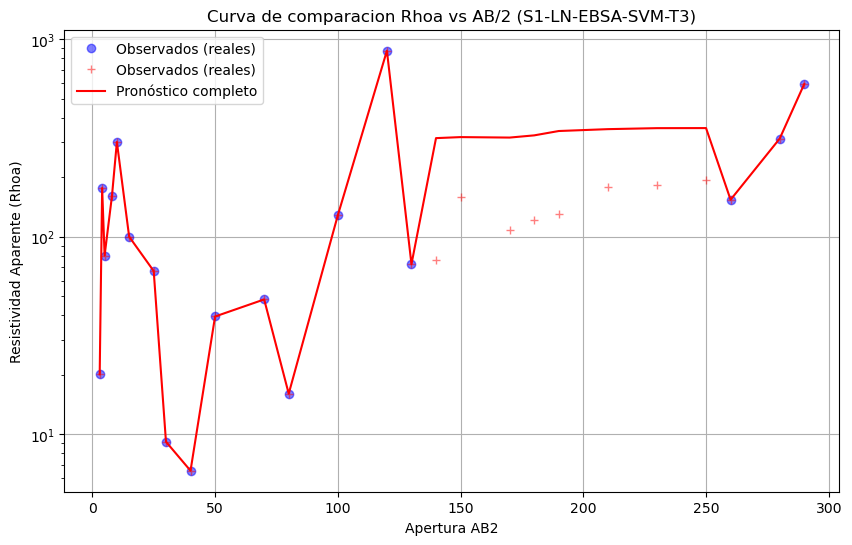

In [13]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = svm_multi.predict(df_new)[0]


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-LN-EBSA-SVM-T3)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-LN-EBSA-SVM-T3.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# EL PINAL S2-ZR-PINAL-EBSA

In [15]:
ab2_values =     [     2,      5,     10,     15,      20,      30,      40,      50,      60,      70,      80,      90,     100,     110]
rhoa_data =      [278.72, 392.90, 596.91, 999.12, 0, 1281.84, 1298.01, 1871.66, 0, 0, 0, 0, 1517.17, 1660.49]
rhoa_original =  [278.72, 392.90, 596.91, 999.12, 1147.81, 1281.84, 1298.01, 1871.66, 2163.81, 1965.60, 1877.89, 1600.08, 1517.17, 1660.49]
n_points = 14

# RF

In [39]:
rf_multi = joblib.load("random_forest_multioutput_v2.joblib")  
X_cols_original = joblib.load("random_forest_feature_columns_v2.joblib")  

Rhoa observados: [278.72, 392.9, 596.91, 999.12, 0, 1281.84, 1298.01, 1871.66, 0, 0, 0, 0, 1517.17, 1660.49]
Rhoa predichos (completos): [278.72, 392.9, 596.91, 999.12, np.float64(823.2102359354874), 1281.84, 1298.01, 1871.66, np.float64(1173.1057306418588), np.float64(966.3281231965356), np.float64(808.3031274910207), np.float64(697.4226620181638), 1517.17, 1660.49]


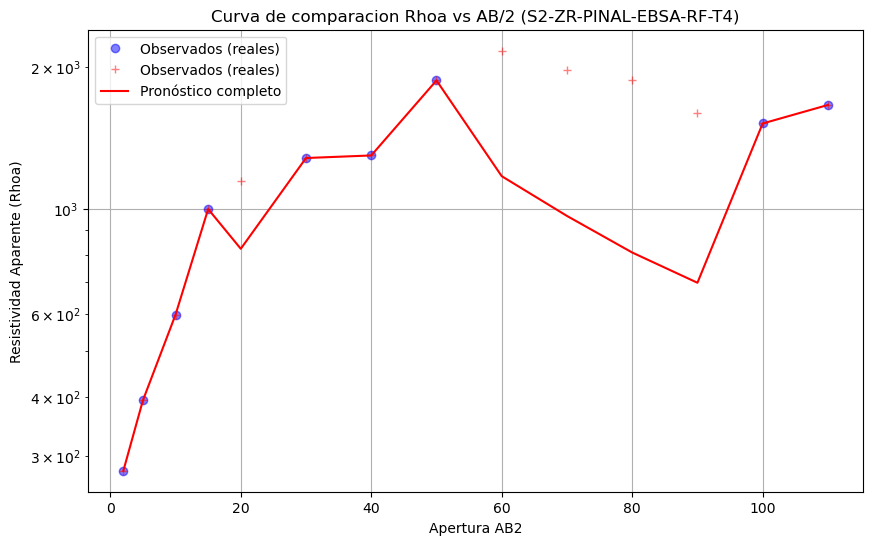

In [40]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original) 
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = rf_multi.predict(df_new)[0]  


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo') 
plt.yscale('log')  
plt.xscale('linear')  
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S2-ZR-PINAL-EBSA-RF-T4)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S2-ZR-PINAL-EBSA-RF-T4.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# GBR

In [41]:
gbr_multi = joblib.load("gbr_multioutput_v2.joblib")
X_cols_original = joblib.load("gbr_feature_columns_v2.joblib")

Rhoa observados: [278.72, 392.9, 596.91, 999.12, 0, 1281.84, 1298.01, 1871.66, 0, 0, 0, 0, 1517.17, 1660.49]
Rhoa predichos (completos): [278.72, 392.9, 596.91, 999.12, np.float64(856.663886157854), 1281.84, 1298.01, 1871.66, np.float64(1488.2706616354403), np.float64(1349.0946627867386), np.float64(821.2321380993257), np.float64(655.2631070566434), 1517.17, 1660.49]


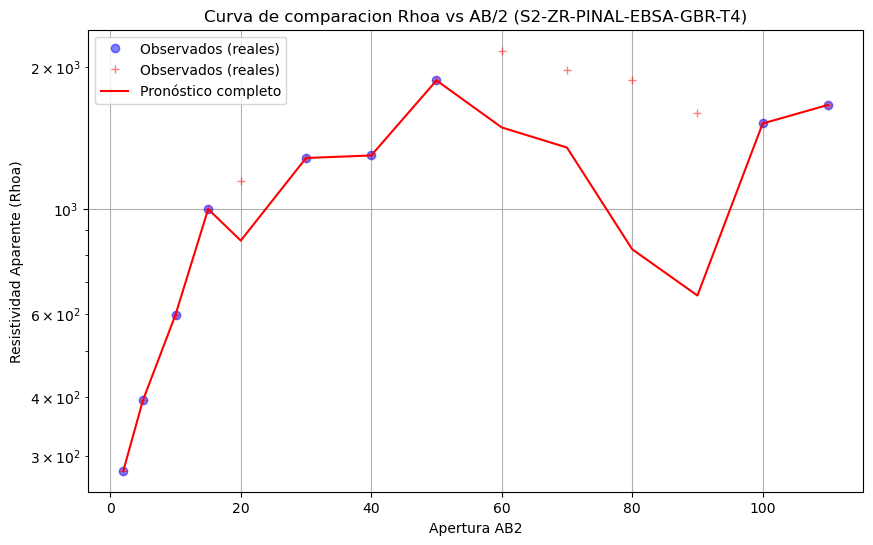

In [42]:

ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)  
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = gbr_multi.predict(df_new)[0]  


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')  
plt.yscale('log')  
plt.xscale('linear') 
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S2-ZR-PINAL-EBSA-GBR-T4)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S2-ZR-PINAL-EBSA-GBR-T4.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# SVM

In [43]:
svm_multi = joblib.load("svm_multioutput_v2.joblib")
X_cols_original = joblib.load("svm_feature_columns_v2.joblib") 

Rhoa observados: [278.72, 392.9, 596.91, 999.12, 0, 1281.84, 1298.01, 1871.66, 0, 0, 0, 0, 1517.17, 1660.49]
Rhoa predichos (completos): [278.72, 392.9, 596.91, 999.12, np.float64(697.5446941227766), 1281.84, 1298.01, 1871.66, np.float64(849.5576248878758), np.float64(876.2731018256306), np.float64(877.321092428297), np.float64(610.0991090906067), 1517.17, 1660.49]


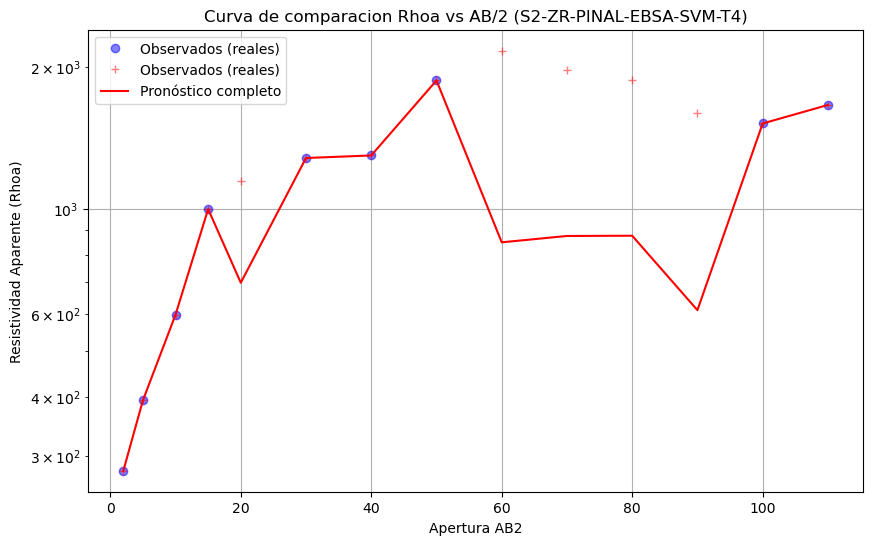

In [44]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = svm_multi.predict(df_new)[0]


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S2-ZR-PINAL-EBSA-SVM-T4)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S2-ZR-PINAL-EBSA-SVM-T4.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# OJO DE AGUA S1-OA-VER

In [45]:
ab2_values =     [   2,     5,   10,   15,   20,   25,   30,   35,   40,   45,   50,   55,    60,   65,    70,    75,   80,    85,   90,   95,   100]
rhoa_data =      [2.49, 15.60, 5.45, 6.15, 6.04, 6.07, 4.74, 0, 0, 0, 0, 0, 13.26, 8.69, 14.39, 12.47, 9.45, 0, 8.36, 9.86, 0]
rhoa_original =  [2.49, 15.60, 5.45, 6.15, 6.04, 6.07, 4.74, 6.09, 5.55, 6.51, 8.66, 5.37, 13.26, 8.69, 14.39, 12.47, 9.45, 24.41, 8.36, 9.86, 28.54]
n_points = 21

# RF

In [46]:
rf_multi = joblib.load("random_forest_multioutput_v2.joblib")  
X_cols_original = joblib.load("random_forest_feature_columns_v2.joblib")  

Rhoa observados: [2.49, 15.6, 5.45, 6.15, 6.04, 6.07, 4.74, 0, 0, 0, 0, 0, 13.26, 8.69, 14.39, 12.47, 9.45, 0, 8.36, 9.86, 0]
Rhoa predichos (completos): [2.49, 15.6, 5.45, 6.15, 6.04, 6.07, 4.74, np.float64(4.340693189227648), np.float64(6.345330557024252), np.float64(7.89707732069142), np.float64(9.10726732472806), np.float64(9.487310938286571), 13.26, 8.69, 14.39, 12.47, 9.45, np.float64(14.059246685044172), 8.36, 9.86, np.float64(17.615359953827987)]


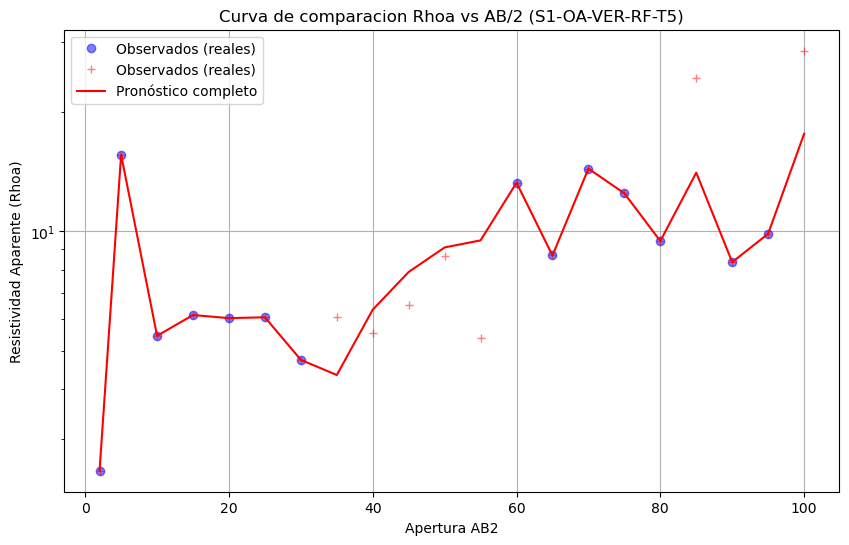

In [47]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = rf_multi.predict(df_new)[0]


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5)
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-OA-VER-RF-T5)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-OA-VER-RF-T5.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# GBR

In [48]:
gbr_multi = joblib.load("gbr_multioutput_v2.joblib")
X_cols_original = joblib.load("gbr_feature_columns_v2.joblib")

Rhoa observados: [2.49, 15.6, 5.45, 6.15, 6.04, 6.07, 4.74, 0, 0, 0, 0, 0, 13.26, 8.69, 14.39, 12.47, 9.45, 0, 8.36, 9.86, 0]
Rhoa predichos (completos): [2.49, 15.6, 5.45, 6.15, 6.04, 6.07, 4.74, np.float64(8.417344899351695), np.float64(5.429702308819843), np.float64(7.580188855587952), np.float64(8.340654486780705), np.float64(9.719360080637756), 13.26, 8.69, 14.39, 12.47, 9.45, np.float64(18.38514119005696), 8.36, 9.86, np.float64(14.400672306527813)]


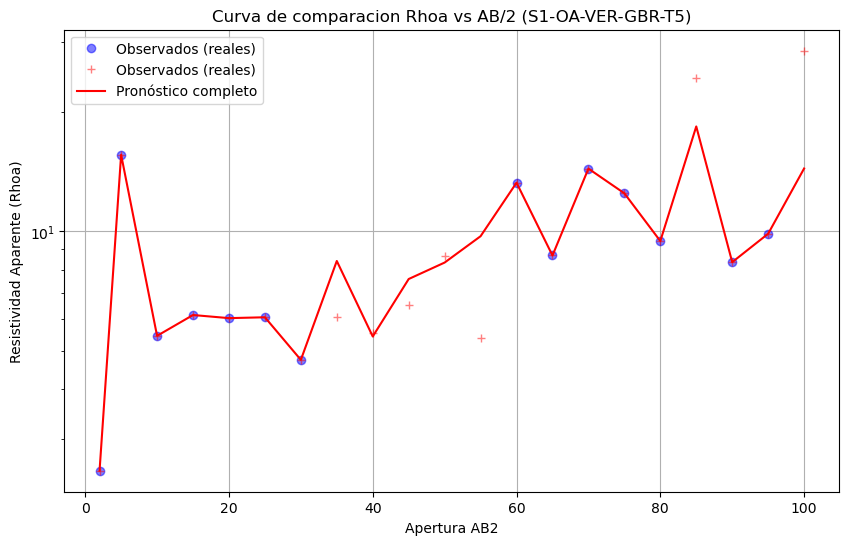

In [49]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)  
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = gbr_multi.predict(df_new)[0]  


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')  
plt.yscale('log')  
plt.xscale('linear') 
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-OA-VER-GBR-T5)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-OA-VER-GBR-T5.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

# SVM

In [50]:
svm_multi = joblib.load("svm_multioutput_v2.joblib")
X_cols_original = joblib.load("svm_feature_columns_v2.joblib") 

Rhoa observados: [2.49, 15.6, 5.45, 6.15, 6.04, 6.07, 4.74, 0, 0, 0, 0, 0, 13.26, 8.69, 14.39, 12.47, 9.45, 0, 8.36, 9.86, 0]
Rhoa predichos (completos): [2.49, 15.6, 5.45, 6.15, 6.04, 6.07, 4.74, np.float64(5.826392490586727), np.float64(7.935916441725908), np.float64(12.924793410064126), np.float64(14.80201742010047), np.float64(-116.69910160607827), 13.26, 8.69, 14.39, 12.47, 9.45, np.float64(39.81601042516104), 8.36, 9.86, np.float64(43.0917189335953)]


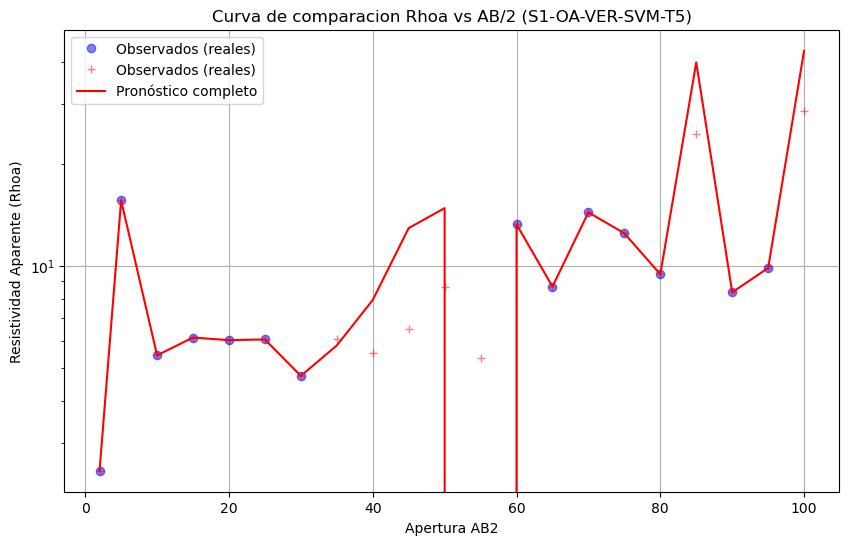

In [51]:
ab2_cols = [f"AB2_{i}" for i in range(1, n_points + 1)]
rhoa_cols = [f"Rhoa_{i}" for i in range(1, n_points + 1)]
indicator_cols = [f"is_observed_{i}" for i in range(1, n_points + 1)]
X_cols = ab2_cols + rhoa_cols + indicator_cols


df_new = pd.DataFrame(columns=X_cols_original)
for i in range(1, n_points + 1):
    df_new[f"AB2_{i}"] = [ab2_values[i-1] if i-1 < len(ab2_values) else 0.0]
    df_new[f"Rhoa_{i}"] = [rhoa_data[i-1] if i-1 < len(rhoa_data) else 0.0]
    df_new[f"is_observed_{i}"] = [1 if (i-1 < len(rhoa_data) and rhoa_data[i-1] != 0) else 0]


for i in range(n_points + 1, 31):
    df_new[f"AB2_{i}"] = [0.0]
    df_new[f"Rhoa_{i}"] = [0.0]
    df_new[f"is_observed_{i}"] = [0]


y_pred = svm_multi.predict(df_new)[0]


rhoa_full = [rhoa_data[i] if i < len(rhoa_data) and rhoa_data[i] != 0 else y_pred[i] for i in range(n_points)]


print("Rhoa observados:", rhoa_data[:n_points])
print("Rhoa predichos (completos):", rhoa_full)


plt.figure(figsize=(10, 6))
plt.plot(ab2_values[:n_points], rhoa_data[:n_points], 'bo', label='Observados (reales)', alpha=0.5)  
plt.plot(ab2_values[:n_points], rhoa_original, 'r+', label='Observados (reales)', alpha=0.5) 
plt.plot(ab2_values[:n_points], rhoa_full, 'r-', label='Pronóstico completo')
plt.yscale('log')
plt.xscale('linear')
plt.xlabel('Apertura AB2')
plt.ylabel('Resistividad Aparente (Rhoa)')
plt.title('Curva de comparacion Rhoa vs AB/2 (S1-OA-VER-SVM-T5)')
plt.legend()
plt.grid(True)

save_path = "imagenes/S1-OA-VER-SVM-T5.png" 
plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()